# Market Regime Detection: Indian Equity Markets

**Question:** Can we describe different market environments, model their persistence, and evaluate the results without future-data leakage?

This project uses NIFTY 50, NIFTY BANK and India VIX closing observations. It compares simple risk/trend rules, K-means, and a Gaussian Hidden Markov Model (HMM). An independent Gaussian mixture provides a density baseline for evaluating whether temporal modelling adds information.

There is no authoritative daily regime label. We therefore evaluate likelihood, persistence, initialization sensitivity and subsequent observed volatility rather than supervised accuracy. No trading profitability is claimed.

**Run:** extract the repository ZIP, install `requirements.txt`, and open this notebook inside the repository. The ZIP includes `data/input/market_prices.csv`; a Git clone requires supplying that local input. All computation is CPU-only. The saved outputs were produced by actually executing the notebook.

In [1]:
import os
for name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[name] = "1"
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / "src/market_regimes").exists():
    ROOT = ROOT.parent
assert (ROOT / "src/market_regimes").exists(), "Open inside the extracted repository."
sys.path.insert(0, str(ROOT / "src"))
from market_regimes.data import load_prices
from market_regimes.features import market_features, chronological_split, MODEL_FEATURES, VALIDATION_END
from market_regimes.baselines import fit_kmeans, rule_threshold, rule_labels
from market_regimes.selection import select_hmm
from market_regimes.hmm import filter_hmm
from market_regimes.pipeline import evaluate_models
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Inspect the supplied daily market data

The supplied aligned extract is attributed by its coverage notes to [NIFTY Indices historical data](https://www.niftyindices.com/reports/historical-data) and [NSE historical India VIX](https://www.nseindia.com/reports-indices-historical-vix). This project validates the local extract; it does not independently redownload and verify every exchange quote.

We restrict observations to dates through 31 December 2025. NIFTY and BANK columns are index closing levels. India VIX is an implied-volatility index, not the historical return volatility we will calculate. No gold or bond data enters the model.

Dates must be unique. Non-positive or non-finite observed values are rejected. Union-calendar rows without NIFTY quotes are removed. Missing auxiliary observations remain missing; there is no forward fill.

In [2]:
quotes, data_audit = load_prices(ROOT / "data/input/market_prices.csv")
display(quotes.head())
display(pd.Series(data_audit, name="Input audit"))

,nifty50,bank_nifty,india_vix
date,,,
2010-01-04,"5,232.2000","9,112.3500",NaN
2010-01-05,"5,277.9000","9,192.1500",NaN
2010-01-06,"5,281.8000","9,223.0000",NaN
2010-01-07,"5,263.1000","9,192.9500",NaN
2010-01-08,"5,244.7500","9,160.7000",NaN


source_path                                                          market_prices.csv
input_sha256                         f5d0c1ad47e76235d7c29cb681371c26152d09763c9c1b...
raw_rows                                                                          4072
rows_after_end_excluded                                                              0
union_rows_without_nifty_excluded                                                  102
nifty_quote_rows                                                                  3970
quote_start                                                                 2010-01-04
quote_end                                                                   2025-12-31
missing_on_nifty_quote_calendar      {'nifty50': 0, 'bank_nifty': 0, 'india_vix': 136}
sources                              {'indices': 'https://www.niftyindices.com/repo...
source_verification                  Local extract attributed by supplied coverage ...
Name: Input audit, dtype: object

## 2. Create features available at the current day's close

For NIFTY closing level $P_t$:

$$r_t=\log(P_t/P_{t-1}),\qquad
\sigma_{t,20}=\sqrt{252}\,\operatorname{sd}(r_{t-19},\ldots,r_t),\qquad
m_{t,20}=\log(P_t/P_{t-20}).$$

The four model inputs are current log return, log 20-session realized volatility, 20-session log momentum, and log India VIX. Log transforms compress skewed positive volatility values. Standardization will be fitted only to the permitted historical training period.

NIFTY–BANK rolling correlation and NIFTY drawdown are additional descriptive columns, not HMM fitting inputs. BANK data therefore enriches interpretation without increasing the model's fitted feature dimension.

Features use only closing observations on or before date $t$. They are unavailable before that close. Decisions made earlier must lag them. Overlapping rolling windows create serial dependence; some observed regime persistence is a consequence of this feature design.

In [3]:
features, feature_audit = market_features(quotes)
display(features[MODEL_FEATURES + ["volatility_20", "nifty_bank_correlation_20"]].head())
display(pd.Series(feature_audit, name="Feature audit"))

,nifty_log_return,log_volatility_20,momentum_20,log_vix,volatility_20,nifty_bank_correlation_20
date,,,,,,
2011-01-03,0.0038,-1.9518,0.0271,2.8326,0.1420,0.8419
2011-01-04,-0.0018,-1.9492,0.0254,2.8350,0.1424,0.8512
2011-01-05,-0.0109,-1.9086,0.0171,2.8837,0.1483,0.8869
2011-01-06,-0.0052,-1.9520,0.0242,2.9014,0.1420,0.8824
2011-01-07,-0.0240,-1.9435,0.0237,3.0359,0.1432,0.7767


rows_in_analysis_period                                                               3718
valid_feature_rows                                                                    3717
rows_excluded_for_incomplete_features                                                    1
excluded_feature_dates                                                        [2024-03-02]
model_features                           [nifty_log_return, log_volatility_20, momentum...
feature_timing                                         available after current day's close
Name: Feature audit, dtype: object

## 3. Fix chronological training, validation and test periods

| Period | Use |
|---|---|
| 2011–2018 | Initial model fitting and initial scaler estimation |
| 2019–2021 | Configuration selection and independent diagnostics |
| 2011–2021 | Refit the selected configurations before testing |
| 2022–2025 | Frozen-model held-out evaluation |

The 2019–2021 validation period contains unusually volatile observations, making extrapolation visible. We do not use a shuffled train/test split. Test data does not select the number of states, scaling, or initialization seed.

Fit-period profiles are retrospective because parameters are estimated using that whole fitting period. Only the post-2021 labels are genuinely held out. Filtered test probabilities update with current observations, while parameters remain frozen.

In [4]:
train, validation, test = chronological_split(features)
refit = features.loc[:VALIDATION_END]
display(pd.DataFrame([
    {"split": name, "start": part.index.min().date(), "end": part.index.max().date(), "observations": len(part)}
    for name, part in [("train", train), ("validation", validation), ("test", test)]
]))
assert train.index.max() < validation.index.min() < test.index.min()

,split,start,end,observations
0,train,2011-01-03,2018-12-31,1981
1,validation,2019-01-01,2021-12-31,745
2,test,2022-01-03,2025-12-31,991


## 4. Implement rules and a K-means baseline

The rules combine two dimensions: elevated trailing volatility versus lower volatility, and positive versus negative trailing momentum. The volatility threshold is the 70th percentile of **initial training** volatility. This yields calm/rising, calm/falling, volatile/rising and volatile/falling descriptions. Calm and bullish are not inherently mutually exclusive concepts.

K-means groups similar standardized feature observations independently of transition order. Compare three and four clusters using validation silhouette, subject to minimum validation cluster-size checks, then refit the selected K to the 2011–2021 period.

Silhouette describes geometric separation, not regime accuracy. Rules and K-means supply useful baselines even if their output changes more frequently than an HMM's.

In [5]:
threshold = rule_threshold(train)
rules = rule_labels(test, threshold)
print("Training-calibrated annualized volatility threshold:", f"{threshold:.2%}")
display(rules.value_counts())
km = fit_kmeans(train, validation, refit)
display(km["selection"])
print("Selected K-means clusters:", km["selected_k"])

Training-calibrated annualized volatility threshold: 16.22%
Selected K-means clusters: 3


rule_regime
Calm rising         516
Calm falling        286
Volatile falling    106
Volatile rising      83
Name: count, dtype: int64

,k,validation_silhouette,minimum_validation_share,validation_clusters_observed
0,3,0.2294,0.2081,3
1,4,0.2143,0.1302,4


## 5. Fit and select a Gaussian Hidden Markov Model

Let $S_t$ be an unobserved state and $X_t$ the standardized feature vector. An HMM assumes:

$$P(S_t=j\mid S_{t-1}=i)=A_{ij},\qquad
X_t\mid S_t=j\sim\mathcal{N}(\mu_j,\Sigma_j).$$

Unlike K-means, the HMM represents both emission distributions and state transitions. We use diagonal emission covariances to keep complexity manageable. Conditional independence and Gaussian emissions are approximations, especially because rolling features overlap and financial returns have heavy tails.

For each candidate state count, fit five initializations and select an adequately completed fit with the highest **training** likelihood. Select three versus four states using mean conditional validation log score. The validation sequence continues from the last training filtered posterior rather than restarting with an unrelated state prior.

Then refit the selected state count on 2011–2021 across five initializations. Again, select the final seed using fitting-period likelihood. A seed's subsequent test result is reported only as a diagnostic and cannot change that choice.

The independent Gaussian mixture uses the same transformed feature dimension and the same component count. It ignores temporal transitions and provides a predictive-density baseline. This is not an equal-parameter-count comparison: the HMM additionally estimates transition parameters.

In [6]:
hmm = select_hmm(train, validation, refit)
display(hmm["selection"])
display(hmm["refit_initializations"])
print("Selected HMM states:", hmm["selected_states"])
print("Selected refit seed:", hmm["model"].random_state)

Selected HMM states: 4
Selected refit seed: 84


,states,selected_training_seed,validation_mean_conditional_log_score,independent_gmm_validation_mean_log_score,validation_states_observed,minimum_validation_state_share
0,3,42,-6.4773,-7.1756,3,0.2027
1,4,84,-6.2514,-7.6694,4,0.2121


,seed,states,train_total_log_likelihood,iterations,last_log_likelihood_gain,iteration_limit_reached,numerically_acceptable
0,7,4,"-10,342.8593",43,0.0007,False,True
1,21,4,"-10,117.1556",119,0.0010,False,True
2,42,4,"-10,342.8595",59,0.0009,False,True
3,63,4,"-10,342.8592",60,0.0007,False,True
4,84,4,"-10,114.9669",197,0.0006,False,True


## 6. Filter states without using future emissions

With $\alpha_{t-1}(i)=P(S_{t-1}=i\mid X_{1:t-1})$, first predict the state distribution:

$$q_t(j)=\sum_i\alpha_{t-1}(i)A_{ij}.$$

Then update it using the current feature observation:

$$\alpha_t(j)=\frac{q_t(j)\,p(X_t\mid S_t=j)}{\sum_k q_t(k)\,p(X_t\mid S_t=k)}.$$

The denominator also supplies the predictive observation likelihood. Computation uses log probabilities and log-sum-exp to avoid numerical underflow.

This is **filtering**, $P(S_t\mid X_{1:t})$. Calling `predict_proba` on a complete HMM sequence normally computes smoothed probabilities using future observations. Viterbi also finds a whole-sequence path. Those retrospective tools should not be presented as same-day live assignments.

Missing feature dates are excluded. The model's transitions and durations are measured between valid feature observations, not calendar days. A different treatment of missing emissions could model the extra hidden-state transition explicitly.

In [7]:
refit_values = hmm["scaler"].transform(refit[MODEL_FEATURES])
test_values = hmm["scaler"].transform(test[MODEL_FEATURES])
refit_probability, refit_scores = filter_hmm(hmm["model"], refit_values)
test_probability, test_scores = filter_hmm(hmm["model"], test_values, refit_probability[-1])
assert np.allclose(test_probability.sum(axis=1), 1)
assert np.isclose(refit_scores.sum(), hmm["model"].score(refit_values))
prefix_probability, _ = filter_hmm(hmm["model"], test_values[:100], refit_probability[-1])
assert np.allclose(prefix_probability, test_probability[:100])
print("Verified probability normalization, sequence likelihood and prefix invariance.")

Verified probability normalization, sequence likelihood and prefix invariance.


## 7. Evaluate already fitted models on held-out observations

Regime IDs R1–R4 are ordered by their **fitting-period** average trailing volatility. This makes labels interpretable without assuming they correspond to four externally true market states. Later observations do not redefine the labels.

Compare hard-label switching and run lengths, mean conditional log scores, state occupancy and initialization sensitivity. Lower switching indicates smoother state descriptions but does not, by itself, prove better detection.

Future 20-session volatility and returns are calculated separately after fitting. They never enter the model input matrix. Because future windows overlap, their summaries are descriptive and no naive independent-sample significance test is reported.

In [8]:
result = evaluate_models(ROOT, quotes, data_audit, features, feature_audit, train, validation, test, km, hmm)
display(pd.Series(result["summary"], name="Held-out summary"))
display(result["comparison"])
display(result["yearly_scores"])

train_period                                                          [2011-01-03, 2018-12-31]
validation_period                                                     [2019-01-01, 2021-12-31]
test_period                                                           [2022-01-03, 2025-12-31]
split_observations                             {'train': 1981, 'validation': 745, 'test': 991}
selected_hmm_states                                                                          4
selected_kmeans_clusters                                                                     3
hmm_covariance                                                                        diagonal
selected_refit_seed                                                                         84
rule_annualized_volatility_threshold                                                    0.1622
test_hmm_mean_conditional_log_score                                                    -3.5167
test_independent_gmm_mean_log_score               

,method,observations,switches,switch_rate,median_run_observations,mean_run_observations
0,Rules,991,106,0.1071,3.0000,9.2617
1,KMeans,991,109,0.1101,1.0000,9.0091
2,HMM,991,40,0.0404,10.0000,24.1707


,year,observations,hmm_mean_log_score,gmm_mean_log_score
0,2022,248,-3.9238,-4.7176
1,2023,246,-3.0594,-4.3396
2,2024,248,-3.7397,-4.4860
3,2025,249,-3.3408,-4.5393


## 8. Interpret state profiles and subsequent volatility

Fitting-period profiles describe the state definitions. Held-out profiles describe what occurred when those definitions were applied later. A low average current volatility state can still contain an unusually large return: no Gaussian market-state model guarantees that every observation is typical.

Inspect subsequent volatility separately from current trailing volatility. A high current-volatility state need not have the highest future volatility: some high-volatility episodes are short-lived or followed by normalization. Rare-state outcomes are also based on small samples.

In [9]:
display(result["fit_profiles"])
display(result["test_profiles"])
display(pd.read_csv(ROOT / "results/model_expected_durations.csv"))

,observations,mean_daily_log_return,mean_trailing_volatility,median_vix,mean_momentum_20,mean_drawdown,mean_nifty_bank_correlation,share
regime,,,,,,,,
R1,612,0.0008,0.0898,13.1812,0.0232,-0.0191,0.8211,0.2245
R2,924,0.0001,0.1302,15.8163,0.0052,-0.0642,0.8691,0.3390
R3,939,0.0003,0.1775,20.4200,0.0095,-0.0901,0.8913,0.3445
R4,251,0.0006,0.3060,29.1900,-0.0269,-0.1764,0.9157,0.0921


,observations,mean_daily_log_return,mean_trailing_volatility,median_vix,mean_momentum_20,mean_drawdown,mean_nifty_bank_correlation,share,future_outcome_count,mean_next_20_volatility,median_next_20_volatility,mean_next_20_log_return
regime,,,,,,,,,,,,
R1,463,0.0007,0.0900,11.9750,0.0167,-0.0246,0.8205,0.4672,443,0.1001,0.0939,0.0080
R2,302,0.0000,0.1265,15.0813,0.0024,-0.0620,0.8456,0.3047,302,0.1315,0.1191,0.0041
R3,190,0.0002,0.1832,19.7987,-0.0004,-0.0775,0.8861,0.1917,190,0.1761,0.1787,0.0062
R4,36,0.0010,0.2899,24.0000,-0.0035,-0.0561,0.9600,0.0363,36,0.1305,0.1589,0.0455


,regime,self_transition_probability,model_expected_duration_observations
0,R1,0.9821,55.7695
1,R2,0.9717,35.3425
2,R3,0.9786,46.7145
3,R4,0.9700,33.2788


## 9. Examine initialization sensitivity and filtering versus smoothing

ARI compares partitions without requiring identical numeric state IDs. Each initialization is fitted on the same pre-test observations; its test assignment is compared with the training-selected reference fit. This is sensitivity to optimization initialization, not a bootstrap confidence interval or supervised accuracy metric.

The smoothed-versus-filtered disagreement share is reported as a diagnostic of how retrospective inference can differ from operational inference. Smoothed assignments are not used in the held-out performance summaries or the saved daily regime timeline.

In [10]:
display(result["robustness"])
print("Filtered/smoothed test-label disagreement:",
      f"{result['summary']['test_filtered_smoothed_disagreement_share']:.2%}")
print("Selected seed was chosen using fitting-period likelihood, even if another seed scores better on test.")

Filtered/smoothed test-label disagreement: 6.05%
Selected seed was chosen using fitting-period likelihood, even if another seed scores better on test.


,seed,states,train_total_log_likelihood,iterations,last_log_likelihood_gain,iteration_limit_reached,numerically_acceptable,test_ari_to_selected_fit,test_mean_log_score
0,7,4,"-10,342.8593",43,0.0007,False,True,0.7424,-3.5683
1,21,4,"-10,117.1556",119,0.0010,False,True,0.9695,-3.5054
2,42,4,"-10,342.8595",59,0.0009,False,True,0.7424,-3.5683
3,63,4,"-10,342.8592",60,0.0007,False,True,0.7424,-3.5682
4,84,4,"-10,114.9669",197,0.0006,False,True,1.0000,-3.5167


## 10. Inspect the figures

The first plot shows the full data overview with chronological boundaries. The market-state chart and probability chart use only genuinely held-out dates. The transition matrix and duration estimates come from the fitting period.

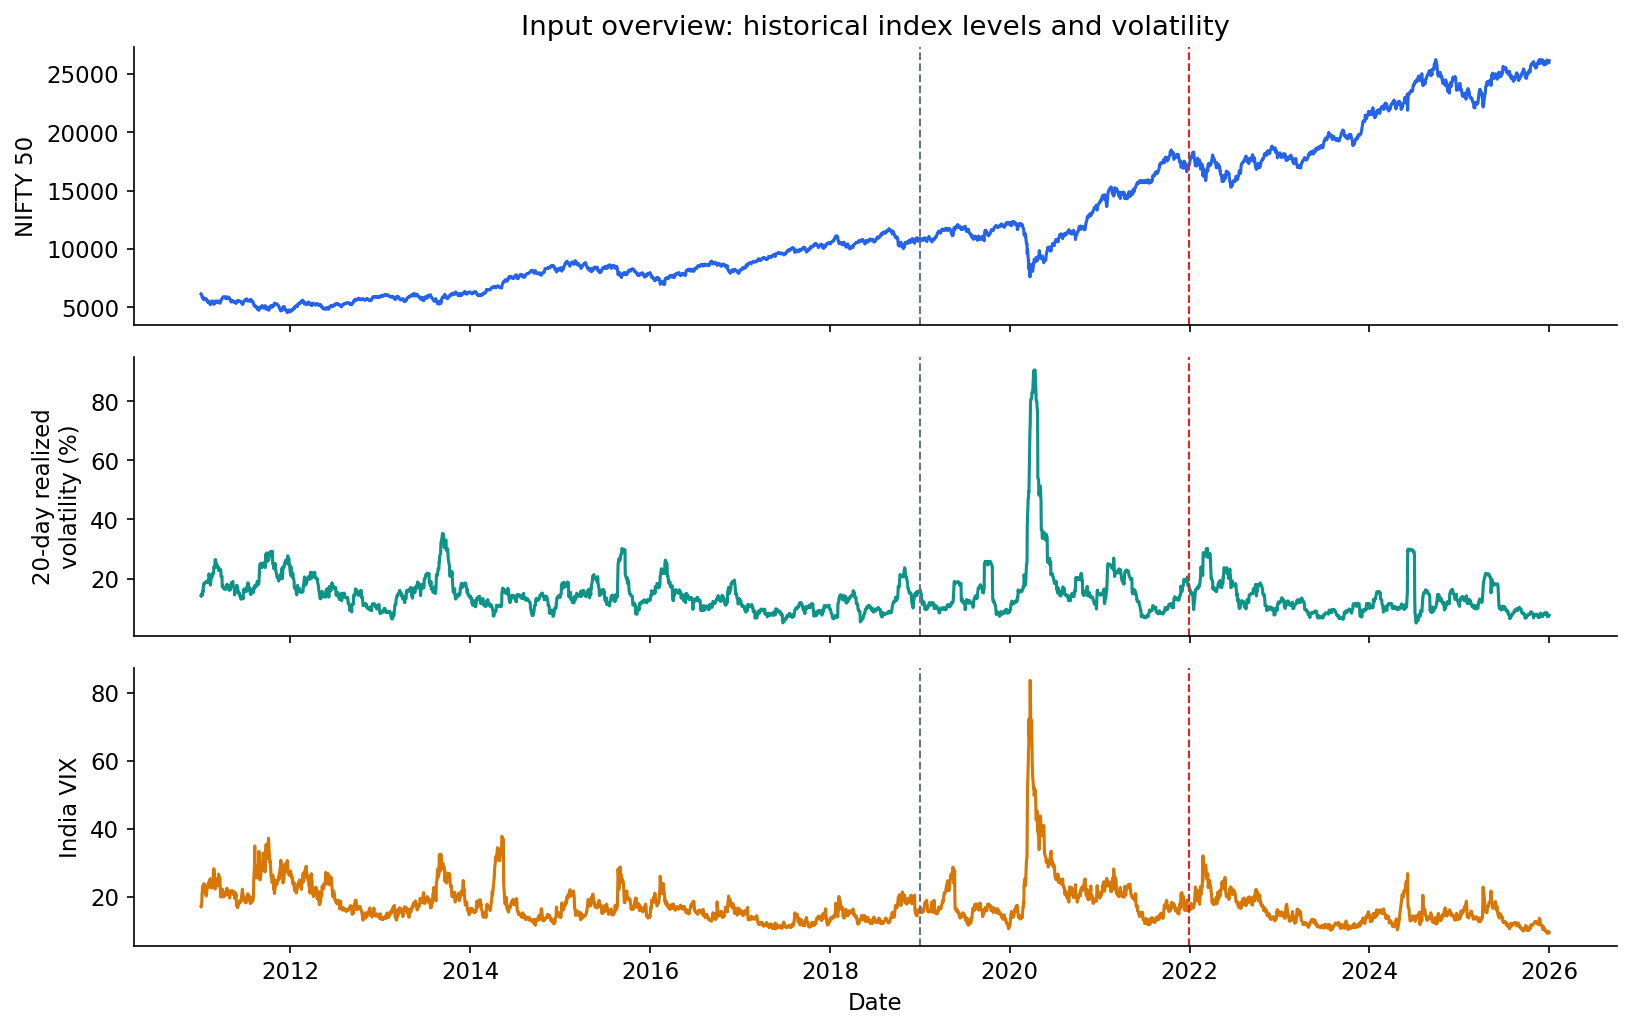

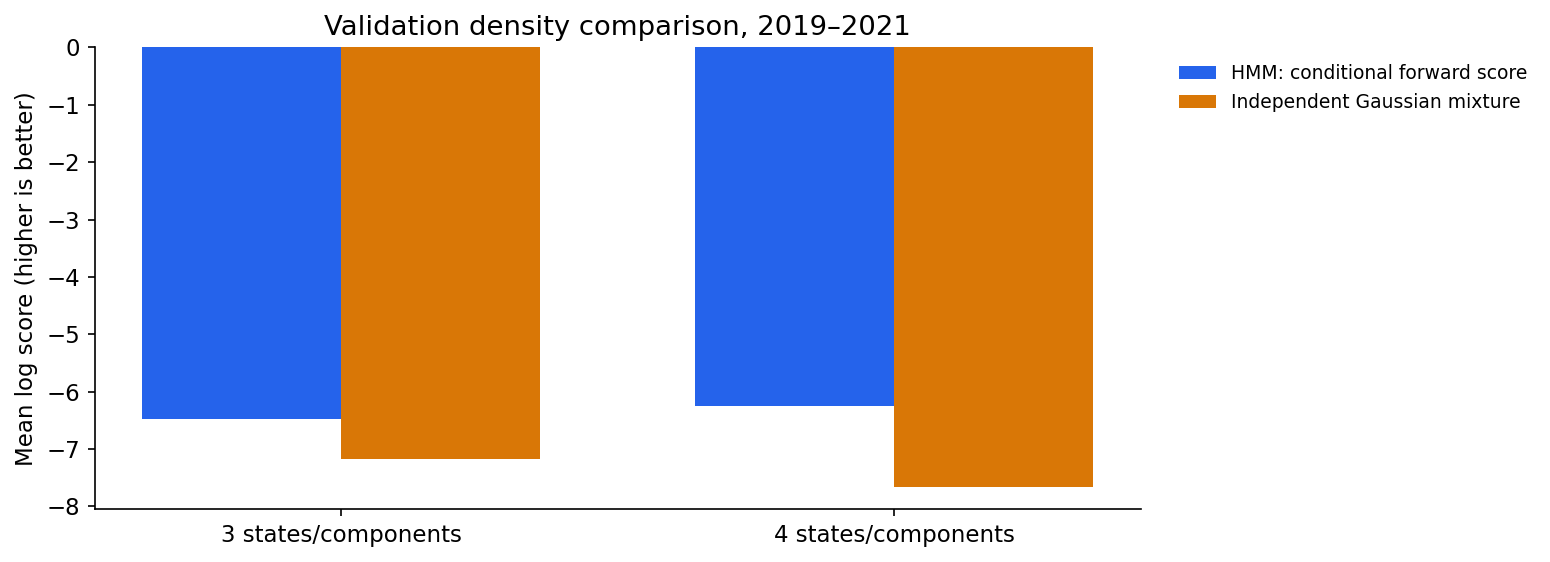

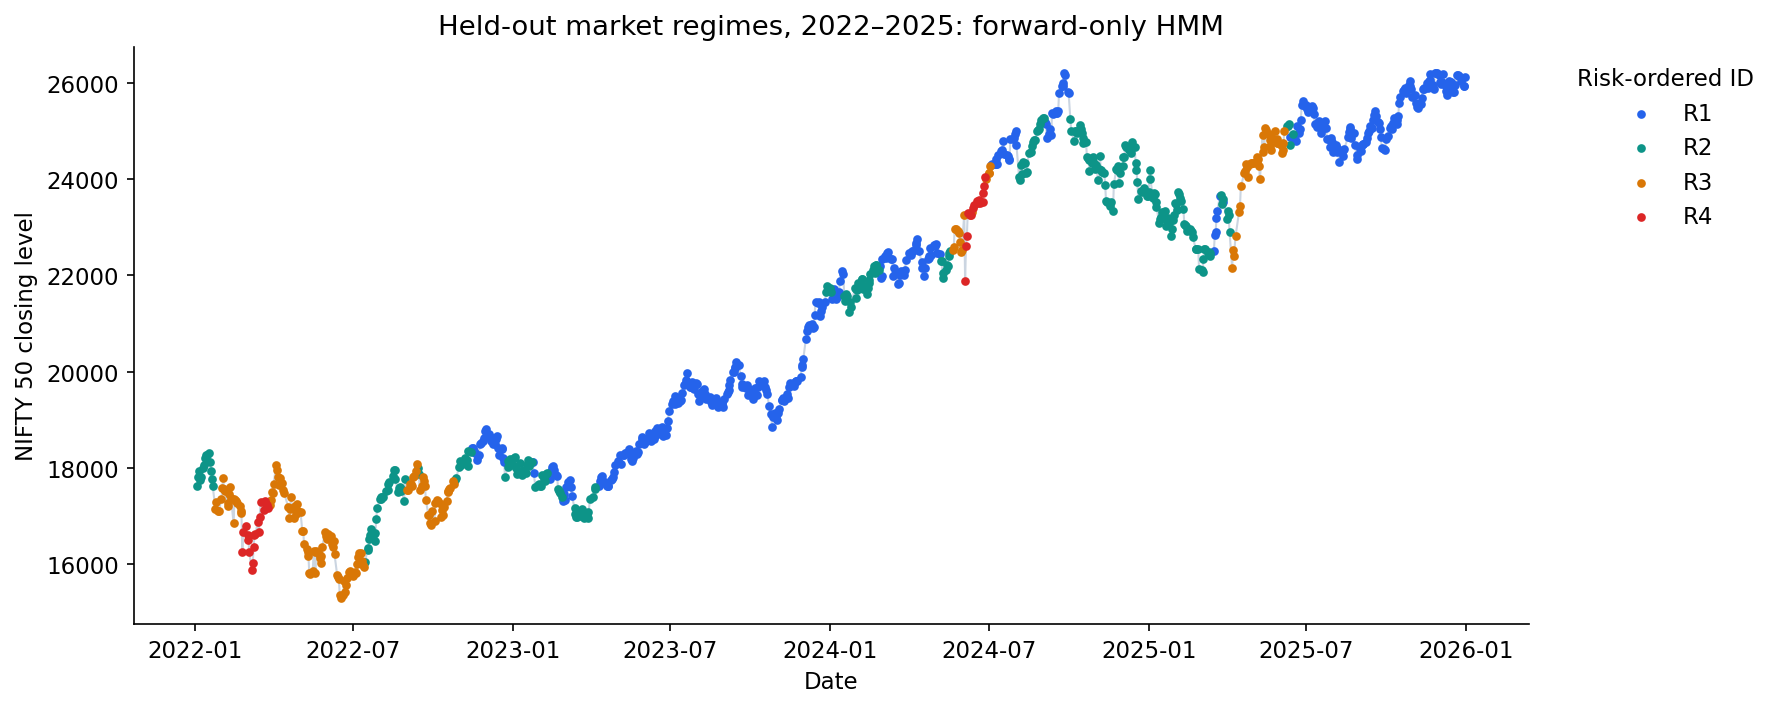

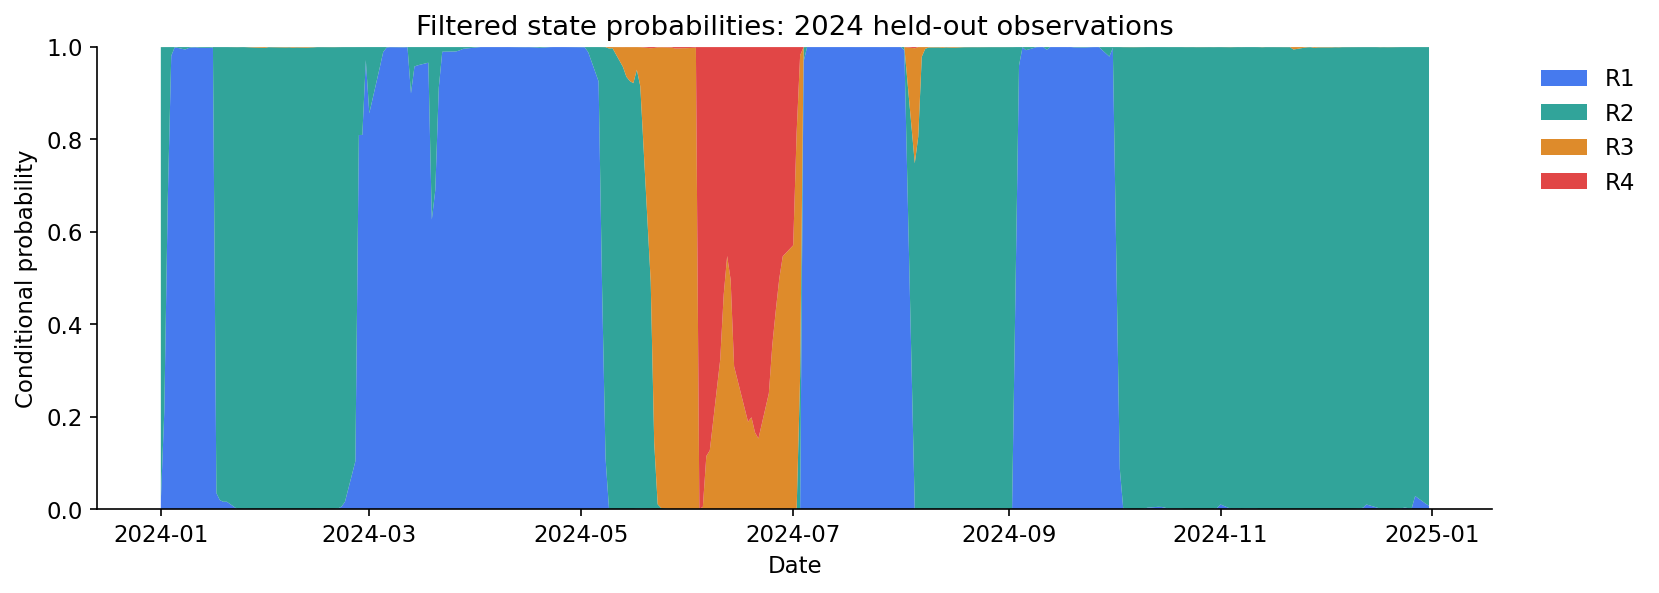

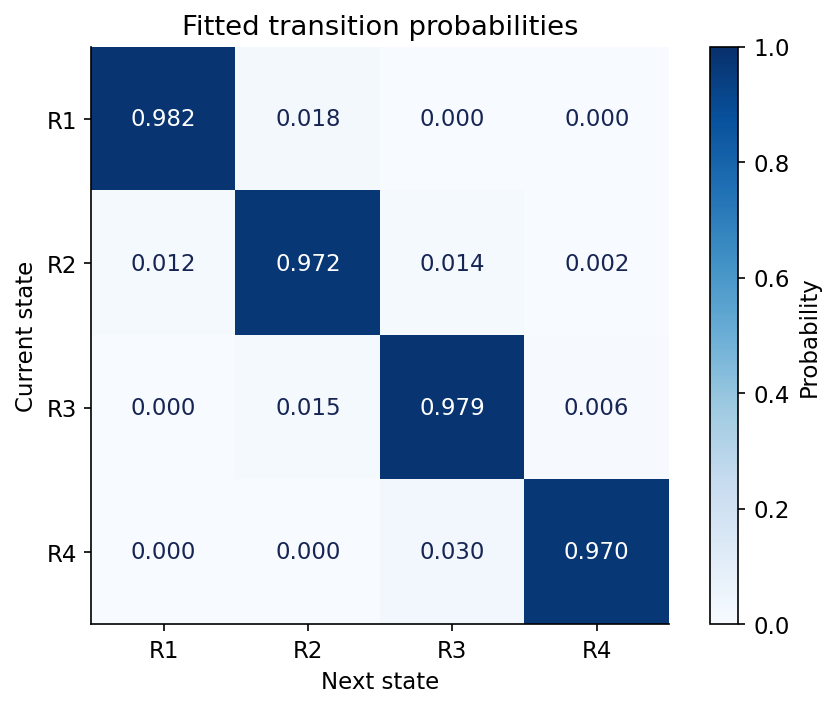

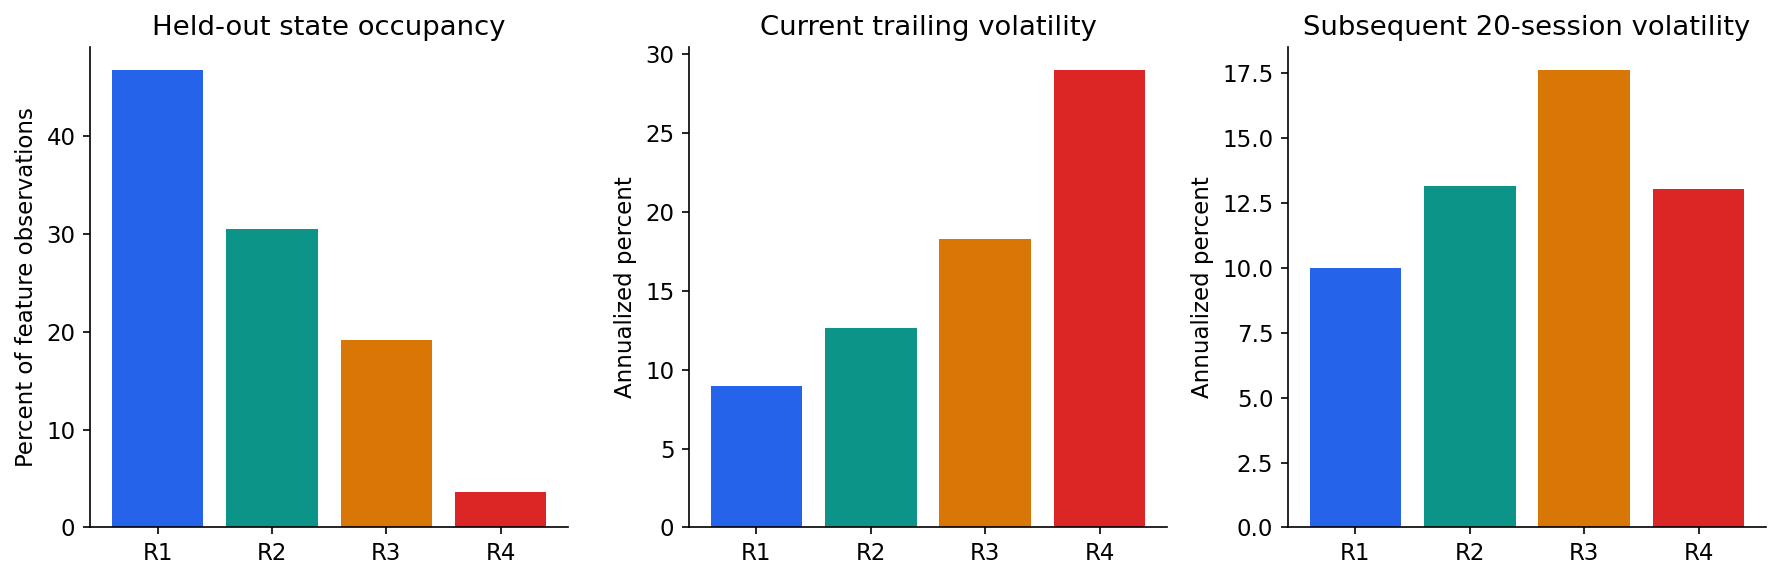

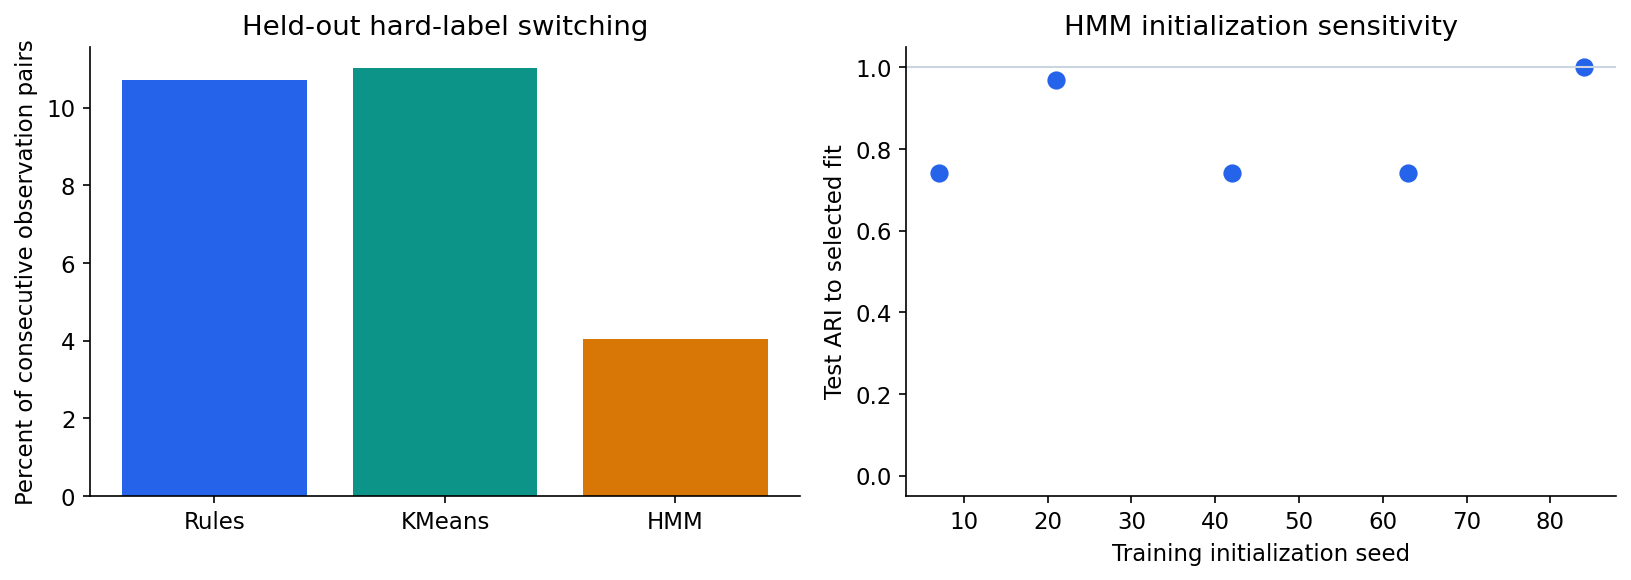

In [11]:
for name in ["01_input_overview.png", "02_validation_selection.png", "03_heldout_market_regimes.png",
             "04_filtered_probabilities.png", "05_transition_matrix.png", "06_test_state_profiles.png",
             "07_persistence_and_robustness.png"]:
    display(Image(filename=str(ROOT / "results/figures" / name)))

## 11. Use the saved frozen model

`artifacts/regime_hmm.joblib` contains the fitted model, scaler, state-name mapping, feature definitions, cutoff date and last fitting-period filtered posterior. To continue the sequence correctly, the input needs historical quotes for feature warmup and the entire post-fit observation history from the expected next date.

```bash
python scripts/score_prices.py data/input/market_prices.csv data/processed/scored_quotes.csv
```

This command scores observations without re-estimating parameters. It is an offline reproducible scoring interface, not a deployed trading service. Applying the model to much later or materially changed markets requires renewed validation.

In [12]:
sys.path.insert(0, str(ROOT / "scripts"))
from score_prices import score
scored = score(ROOT / "data/input/market_prices.csv", ROOT / "data/processed/scored_quotes.csv",
               ROOT / "artifacts/regime_hmm.joblib")
display(scored.tail())
assert scored.regime.tolist() == result["test_labels"].tolist()

,date,regime,max_filtered_probability,conditional_log_score,probability_R1,probability_R2,probability_R3,probability_R4
986,2025-12-24,R1,1.0000,-7.8441,1.0000,0.0000,0.0000,0.0000
987,2025-12-26,R1,1.0000,-8.3112,1.0000,0.0000,0.0000,0.0000
988,2025-12-29,R1,1.0000,-6.6087,1.0000,0.0000,0.0000,0.0000
989,2025-12-30,R1,1.0000,-6.3450,1.0000,0.0000,0.0000,0.0000
990,2025-12-31,R1,1.0000,-6.7109,1.0000,0.0000,0.0000,0.0000


## 12. Findings and practical limits

The following statements are produced from the actual results. This ensures that they update when the model or data changes.

In [13]:
s = result["summary"]
switches = result["comparison"].set_index("method")
print(f"Selected {s['selected_hmm_states']} HMM states and {s['selected_kmeans_clusters']} K-means clusters.")
print(f"Evaluated {s['split_observations']['test']:,} held-out feature observations.")
print(f"Hard-label switching: HMM {switches.loc['HMM','switch_rate']:.2%}; K-means {switches.loc['KMeans','switch_rate']:.2%}; rules {switches.loc['Rules','switch_rate']:.2%}.")
print(f"Mean held-out density score: HMM {s['test_hmm_mean_conditional_log_score']:.3f}; independent mixture {s['test_independent_gmm_mean_log_score']:.3f} nats/observation.")
print(f"Median initialization ARI to selected fit: {s['initialization_median_test_ari']:.3f}.")
print("The highest current-volatility state does not necessarily imply the highest subsequent volatility.")

Selected 4 HMM states and 3 K-means clusters.
Evaluated 991 held-out feature observations.
Hard-label switching: HMM 4.04%; K-means 11.01%; rules 10.71%.
Mean held-out density score: HMM -3.517; independent mixture -4.521 nats/observation.
Median initialization ARI to selected fit: 0.742.
The highest current-volatility state does not necessarily imply the highest subsequent volatility.


**What the project demonstrates:** careful financial time-series preparation, chronological model selection, probabilistic state inference, explicit forward filtering, comparison with baselines, and meaningful robustness diagnostics.

**What remains uncertain:** the chosen states are statistical approximations. They depend on feature choice, Gaussian assumptions, the selected state-count range, initialization and the fitted historical period. Rolling features create dependence that can itself increase persistence. Posterior certainty is not independently calibrated confidence in a true economic state.

**Next extensions:** Student-t emissions, full-covariance sensitivity, walk-forward parameter refitting, missing-emission handling, different volatility horizons, and validation on another market. A regime-based investment strategy would be a separate project requiring implementable execution timing, an investable benchmark, turnover and transaction costs.

**References:**
- [NIFTY Indices historical data](https://www.niftyindices.com/reports/historical-data)
- [NSE historical India VIX](https://www.nseindia.com/reports-indices-historical-vix)
- [hmmlearn tutorial](https://hmmlearn.readthedocs.io/en/stable/tutorial.html)
- [hmmlearn API and decoding definitions](https://hmmlearn.readthedocs.io/en/stable/api.html)